# Dataset for Modeling

## Libraries

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent ))

In [2]:
from src.dominick import DominickDataLoader, DominickDataSaver
from src.eda import EDA

## Loader

In [3]:
loader = DominickDataLoader()
df = loader.load("dominick_features.csv")

## Filtering
> For our porpuse, we filter those lines that `unit_sold = 0`. Morevoer, for consistency, we filter:
1. total_price > 0.05

In [4]:
df = df[df["units_sold"] != 0]
df = df[df["total_price"] > 0.05]

## EDA

In [5]:
eda = EDA()

In [6]:
# NaNs?
eda.analyze_nans(df)

,n_nans,pct_nans
category_code,0,0.0
upc_code,0,0.0
units_per_case,0,0.0
product_item_code,0,0.0
store_code,0,0.0
week_id,0,0.0
units_sold,0,0.0
units_per_deal,0,0.0
total_price,0,0.0
gross_margin_pct,0,0.0


### Correlation

<Axes: title={'center': 'Spearman correlation by store'}, xlabel='Spearman correlation', ylabel='Number of stores'>

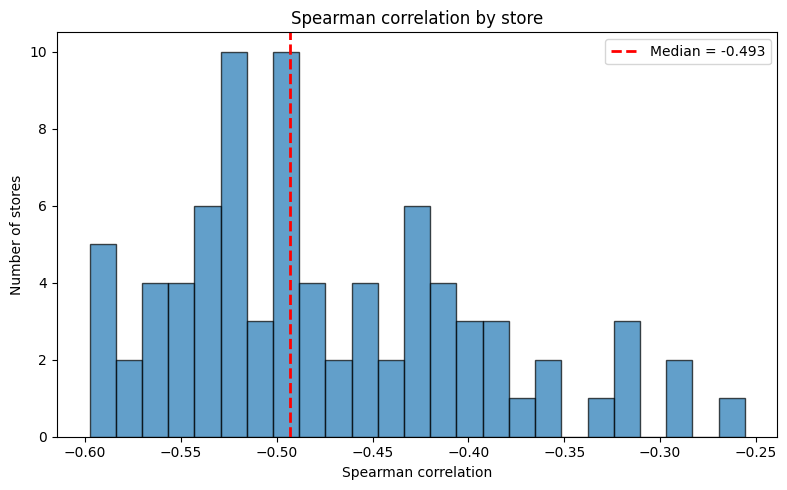

In [7]:
# Correlations
eda.plot_correlations(eda.analyze_correlations(df, "log_liters_sold", "log_price_per_liter"))

=== Global Correlation Analysis ===

Pearson: r = -0.4944, p = 0.0000e+00
Spearman: ρ = -0.4830, p = 0.0000e+00

Linear regression:
  R² = 0.2445
  Elasticity (β) = -1.7476
  Intercept = 3.3810
  p-value = 0.0000e+00


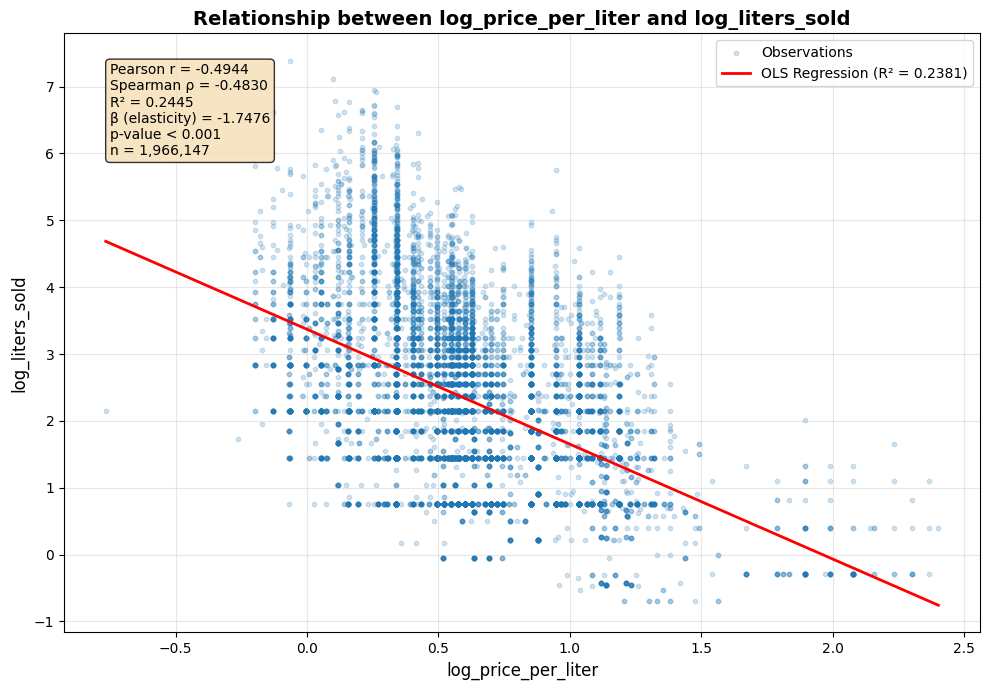

In [8]:
x_col = "log_price_per_liter"
y_col = "log_liters_sold"

# 1. Correlation and R² (you have it)
print("=== Global Correlation Analysis ===")
corr_stats = eda.analyze_global_correlation(df, x_col, y_col)

print(f"\nPearson: r = {corr_stats['pearson']['correlation']:.4f}, p = {corr_stats['pearson']['pvalue']:.4e}")
print(f"Spearman: ρ = {corr_stats['spearman']['correlation']:.4f}, p = {corr_stats['spearman']['pvalue']:.4e}")
print(f"\nLinear regression:")
print(f"  R² = {corr_stats['regression']['r_squared']:.4f}")
print(f"  Elasticity (β) = {corr_stats['regression']['slope']:.4f}")
print(f"  Intercept = {corr_stats['regression']['intercept']:.4f}")
print(f"  p-value = {corr_stats['regression']['pvalue']:.4e}")

# 2. Scatter plot with regression
fig = eda.plot_scatter_regression(
    df, x_col, y_col, 
    sample_size=10000,
    stats_dict=corr_stats,
    alpha=0.2
)



### Distribution

In [9]:
# Distributions analysis
columns_to_analyze = ["log_price_per_liter", "log_liters_sold"]

# 1. Descriptive statistics and normality test
stats = eda.analyze_distributions(df, columns_to_analyze)
print("=== Descriptive Statistics ===")
for col, s in stats.items():
    print(f"\n{col}:")
    print(f"  Mean: {s['mean']:.4f}")
    print(f"  Median: {s['median']:.4f}")
    print(f"  Std: {s['std']:.4f}")
    print(f"  Min: {s['min']:.4f}, Max: {s['max']:.4f}")
    print(f"  Q25: {s['q25']:.4f}, Q75: {s['q75']:.4f}")
    print(f"  Skewness: {s['skewness']:.4f}, Kurtosis: {s['kurtosis']:.4f}")
    print(f"  Normality test ({s['normality_test']['test_name']}): p-value = {s['normality_test']['pvalue']:.4f}")
    print(f"  Is normal? {s['normality_test']['is_normal']}")

=== Descriptive Statistics ===

log_price_per_liter:
  Mean: 0.6191
  Median: 0.6026
  Std: 0.3636
  Min: -0.9916, Max: 3.2619
  Q25: 0.3420, Q75: 0.8516
  Skewness: 0.5938, Kurtosis: 1.3288
  Normality test (Kolmogorov-Smirnov): p-value = 0.0000
  Is normal? False

log_liters_sold:
  Mean: 2.2990
  Median: 2.1421
  Std: 1.2851
  Min: -0.6936, Max: 8.7231
  Q25: 1.4489, Q75: 3.1537
  Skewness: 0.5070, Kurtosis: 0.0758
  Normality test (Kolmogorov-Smirnov): p-value = 0.0000
  Is normal? False


## Descriptive Statistics (Beer)

### `log_price_per_liter`

The distribution is fairly centered because the mean (0.6191) and median (0.6026) are close, but it shows a **right tail** (skewness 0.5938), meaning there are weeks/items with noticeably higher price per liter (often due to smaller formats, premium/import items, or promotions affecting effective prices). The Kolmogorov–Smirnov test rejects normality (p-value 0.0000), which is typical in large retail datasets and usually reflects a mix of pack sizes, pricing regimes, and promotional behavior rather than a data issue.

- **Q25 = 0.3420** and **Q75 = 0.8516** mean that the *middle 50%* of your observations fall between these two values.  
- That range is a “normal” price band (robust, not driven by extreme outliers).  

**Summary stats:** mean 0.6191, median 0.6026, std 0.3636, min -0.9916, max 3.2619, Q25 0.3420, Q75 0.8516.

---

### `log_liters_sold`

The distribution also has a **right tail** (skewness 0.5070), indicating occasional weeks with very large volumes sold—often driven by big multipacks (e.g., 24/12oz or 30/12oz), strong promotions, or store-level spikes. Normality is rejected by the KS test (p-value 0.0000), which is expected for demand data: even after logging, sales are rarely perfectly bell-shaped because of heterogeneity across stores, weeks, and promotional intensity.

- **Q25 = 1.4489** and **Q75 = 3.1537** define the *middle 50%* of weekly demand.  
- This gives you a clear “typical demand” band and shows how variable demand is even without looking at extreme promo spikes.  

**Summary stats:** mean 2.2990, median 2.1421, std 1.2851, min -0.6936, max 8.7231, Q25 1.4489, Q75 3.1537.



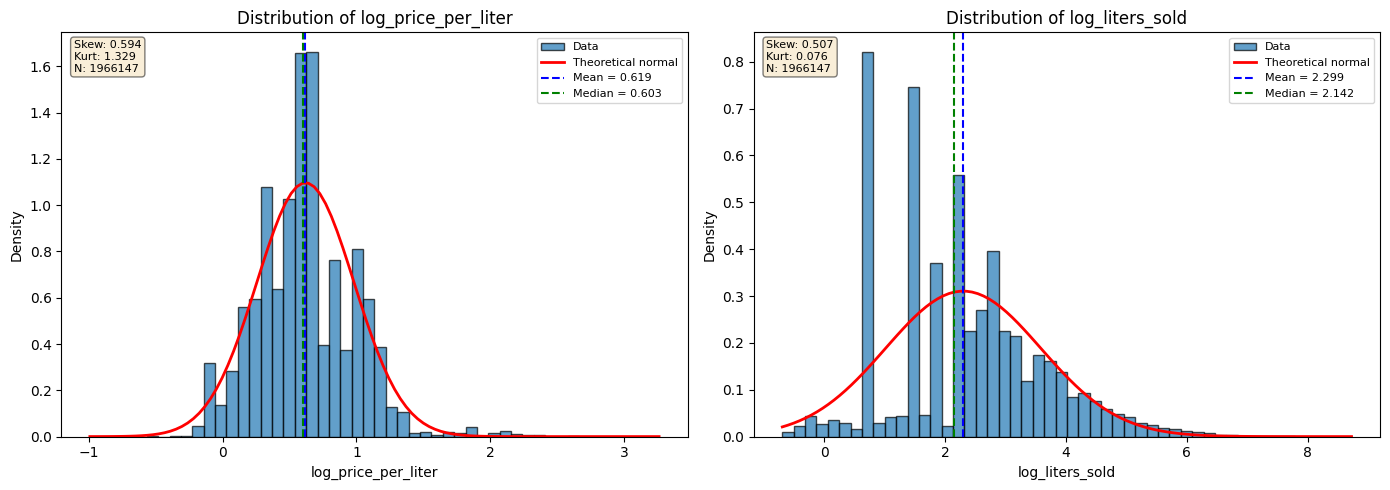

In [10]:
# 2. Histograms
fig = eda.plot_distributions(df, columns_to_analyze, bins=50, stats_dict=stats)

### Outliers

In [11]:
# 3. Outliers analysis
outliers_std = eda.analyze_outliers(df, columns_to_analyze, method='std', n_std=3)
print("\n=== Outliers (±3 std) ===")
print(outliers_std)

outliers_iqr = eda.analyze_outliers(df, columns_to_analyze, method='iqr')
print("\n=== Outliers (IQR) ===")
print(outliers_iqr)


=== Outliers (±3 std) ===
              variable  n_outliers  pct_outliers  lower_bound  upper_bound  \
0  log_price_per_liter       20710          1.05      -0.4717       1.7099   
1      log_liters_sold        8979          0.46      -1.5563       6.1543   

   method  
0  ±3 std  
1  ±3 std  

=== Outliers (IQR) ===
              variable  n_outliers  pct_outliers  lower_bound  upper_bound  \
0  log_price_per_liter       23986          1.22      -0.4226       1.6162   
1      log_liters_sold       20569          1.05      -1.1082       5.7108   

      method  
0  IQR (1.5)  
1  IQR (1.5)  


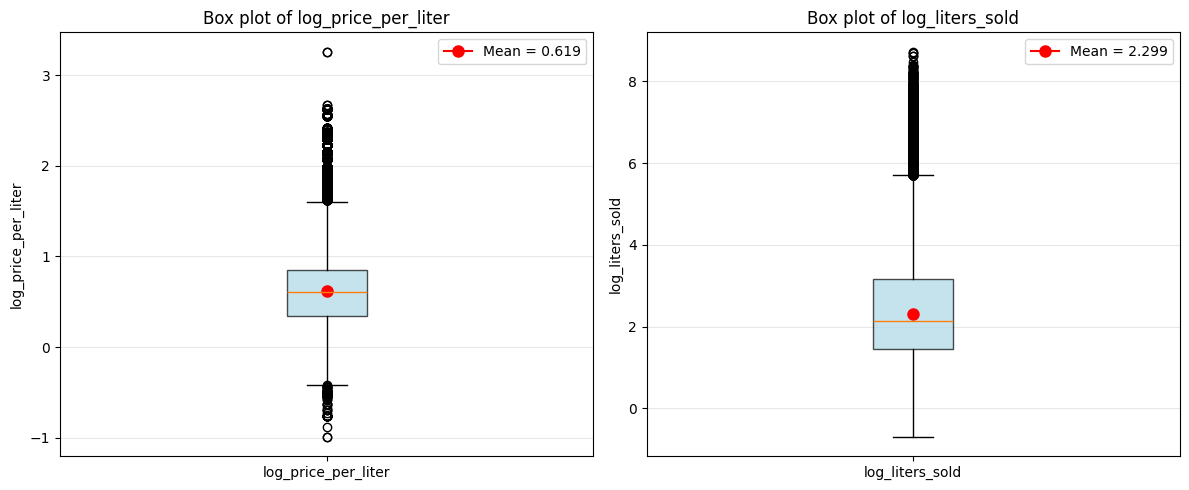

In [12]:
# 4. Box plots
fig = eda.plot_boxplots(df, columns_to_analyze)

### Temporal Analysis

In [13]:
# Temporal Aggregated
time_col = "week_id"
value_cols = ["log_price_per_liter", "log_liters_sold"]

# 1. Aggregate by time
print("=== Temporal Aggregation ===")
ts_df = eda.aggregate_time_series(df, time_col, value_cols, agg_func='mean')
print(f"Time series: {len(ts_df)} weeks")
print(ts_df.head())

=== Temporal Aggregation ===
Time series: 302 weeks
   week_id  log_price_per_liter  log_liters_sold
0       91             0.491463         2.602143
1       92             0.485244         2.670613
2       93             0.474471         2.646840
3       94             0.470206         2.629505
4       95             0.471885         2.784683


In [14]:
# 2. Analyze trends
print("\n=== Trend Analysis ===")
trend_stats = {}
for col in value_cols:
    trend = eda.analyze_trend(ts_df, time_col, col)
    trend_stats[col] = trend
    print(f"\n{col}:")
    print(f"  Slope: {trend['slope']:.6f}")
    print(f"  R²: {trend['r_squared']:.4f}")
    print(f"  p-value: {trend['pvalue']:.4e}")
    print(f"  Trend: {trend['trend_direction']}")


=== Trend Analysis ===

log_price_per_liter:
  Slope: 0.001938
  R²: 0.7432
  p-value: 1.5095e-90
  Trend: upward

log_liters_sold:
  Slope: -0.002731
  R²: 0.5752
  p-value: 1.0122e-57
  Trend: downward


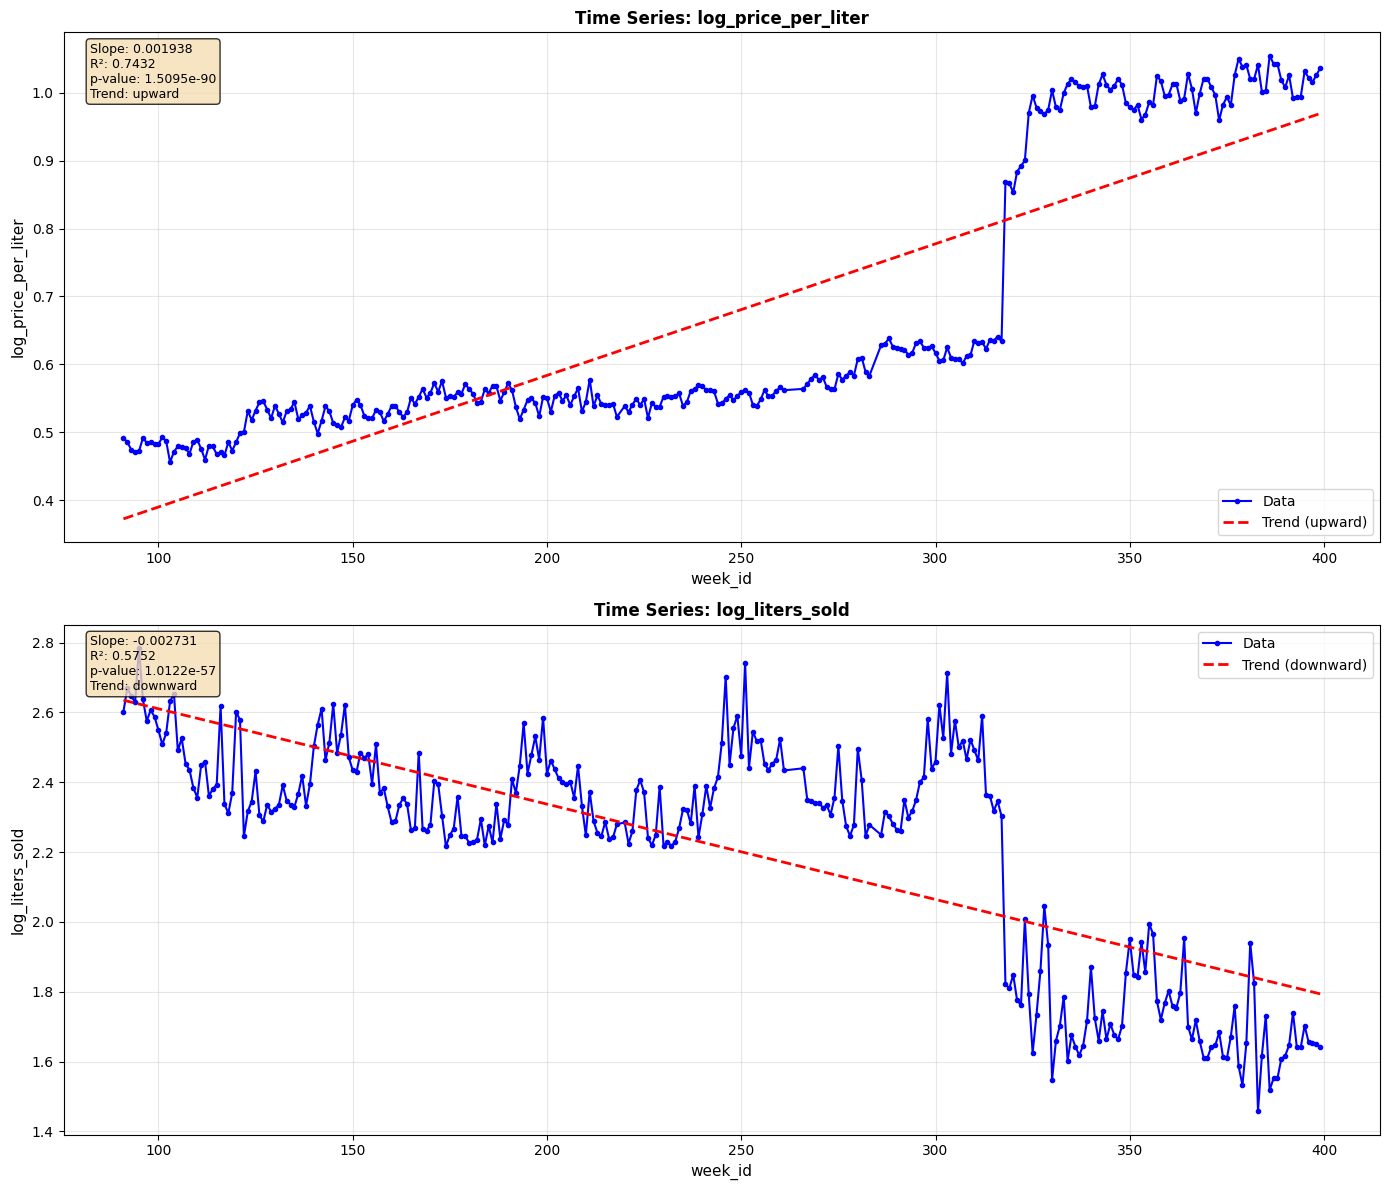

In [15]:
# 3. Plot time series with trends
fig = eda.plot_time_series(ts_df, time_col, value_cols, trend_stats=trend_stats)


=== Autocorrelation Analysis ===

log_price_per_liter:
  Has autocorrelation?: True
  Significant lags: [1, 2, 3, 4, 5]

log_liters_sold:
  Has autocorrelation?: True
  Significant lags: [1, 2, 3, 4, 5]


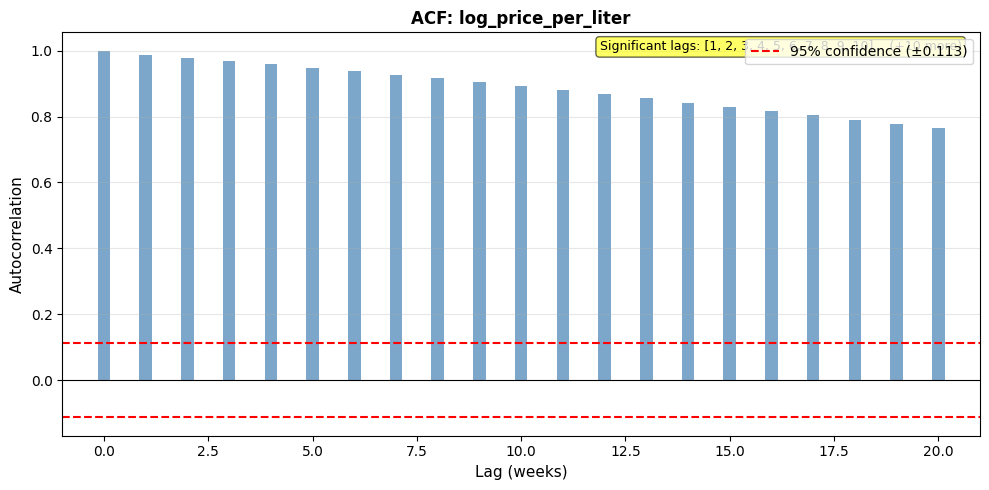

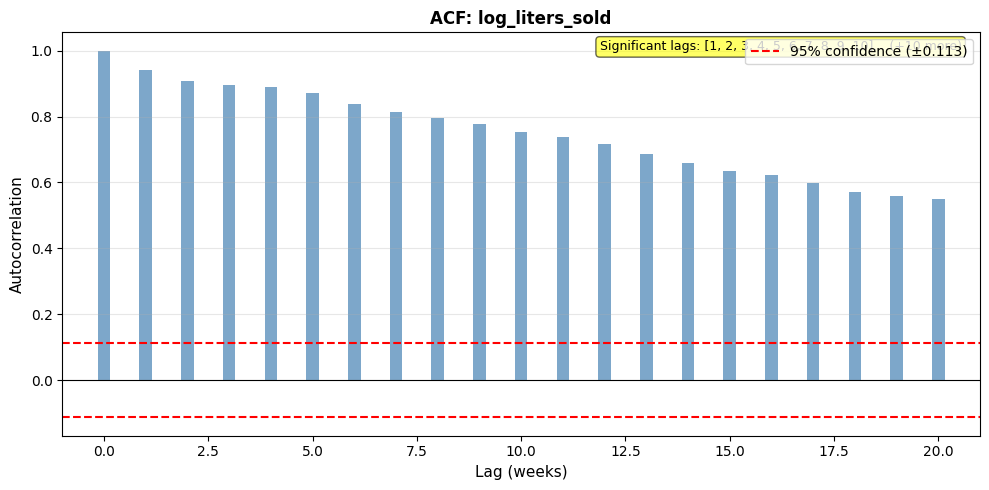

In [16]:
# 4. Autocorrelation analysis
print("\n=== Autocorrelation Analysis ===")
for col in value_cols:
    acf_result = eda.analyze_autocorrelation(ts_df, col, max_lags=20)
    print(f"\n{col}:")
    print(f"  Has autocorrelation?: {acf_result['has_autocorrelation']}")
    if acf_result['significant_lags']:
        print(f"  Significant lags: {acf_result['significant_lags'][:5]}")
    
    # Graficar ACF
    fig = eda.plot_autocorrelation(acf_result, title=f"ACF: {col}")

In [17]:
# 5. Seasonality detection (annual = 52 weeks)
print("\n=== Seasonality Detection ===")
for col in value_cols:
    seasonality = eda.detect_seasonality(ts_df, col, period=52)
    print(f"\n{col}:")
    if seasonality.get('note'):
        print(f"  {seasonality['note']}")
    else:
        print(f"  ACF in lag {seasonality['period_tested']}: {seasonality['seasonal_acf']:.4f}")
        print(f"  Is seasonal?: {seasonality['is_seasonal']}")


=== Seasonality Detection ===

log_price_per_liter:
  ACF in lag 52: 0.3789
  Is seasonal?: True

log_liters_sold:
  ACF in lag 52: 0.3406
  Is seasonal?: True


## Top 5 Products - Store

In [21]:
top5_product_store = (
    df.groupby(["upc_code", "store_code"], as_index=False).size()
    .nlargest(20, "size")
    .rename(columns={"size": "n_filas"})
)
top5_product_store

,upc_code,store_code,n_filas
1763,1820000784,94,302
1778,1820000784,112,302
1792,1820000784,131,302
1793,1820000784,132,302
6128,3410010505,102,302
6134,3410010505,109,302
6149,3410010505,129,302
21501,8066095605,100,302
21524,8066095605,129,302
21529,8066095605,134,302


## Features selection for DL

In [19]:
df_final = df[["store_code", "upc_code", "week_id", "liters_per_upc", "on_promo", "promo_B", "promo_C", "promo_S", "log_price_per_liter", "log_liters_sold"]].copy()
df_final.head()

,store_code,upc_code,week_id,liters_per_upc,on_promo,promo_B,promo_C,promo_S,log_price_per_liter,log_liters_sold
0,2,294,298,4.258588,False,0,0,0,-0.485808,3.846833
1,2,294,299,4.258588,False,0,0,0,-0.528650,3.646162
2,2,294,300,4.258588,False,0,0,0,-0.536656,3.240697
3,2,294,301,4.258588,False,0,0,0,-0.353679,3.058376
4,2,294,302,4.258588,False,0,0,0,-0.536656,1.448938


## Save

In [19]:
## Save
saver = DominickDataSaver()
saver.save("elasticity_dataset.csv", df_final)